# Setup
In this notebook you'll be plotting bar plots using MatPlotLib and Seaborn.

Import necessary libraries and download the "spscientist/students-performance-in-exams" dataset from kaggle and read it to a Pandas DataFrame.

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import os

#UNCOMMENT COMMANDS BELOW TO DOWNLOAD, only run unzip once or else the code will crash. once you unzip, just comment it back out

! kaggle datasets download spscientist/students-performance-in-exams
! unzip students-performance-in-exams.zip

Dataset URL: https://www.kaggle.com/datasets/spscientist/students-performance-in-exams
License(s): unknown
100%|██████████████████████████████████████| 8.70k/8.70k [00:00<00:00, 9.15MB/s]

Archive:  students-performance-in-exams.zip
  inflating: StudentsPerformance.csv  


In [12]:
df = pd.read_csv("StudentsPerformance.csv")

In [13]:
df.head(15)

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
5,female,group B,associate's degree,standard,none,71,83,78
6,female,group B,some college,standard,completed,88,95,92
7,male,group B,some college,free/reduced,none,40,43,39
8,male,group D,high school,free/reduced,completed,64,64,67
9,female,group B,high school,free/reduced,none,38,60,50


# Bar Plots

(TASK 1): Using seaborn, make a countplot graphing the count of each ethnicity

Text(0.5, 1.0, 'Count of Each Race/Ethnicity')

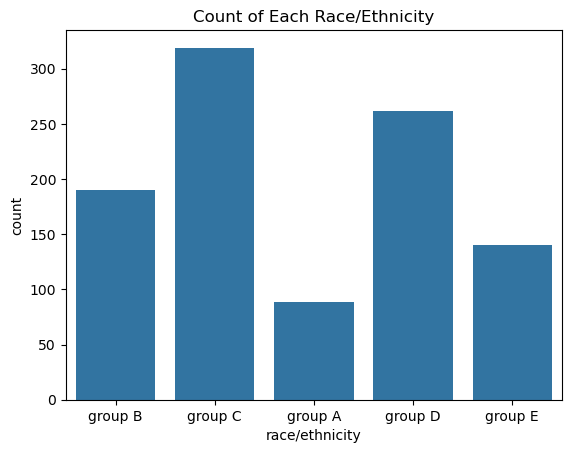

In [14]:
sns.countplot(data=df, x="race/ethnicity")
plt.title("Count of Each Race/Ethnicity")

(TASK 2):
Next, try doing the same thing with the matplotlib.

To get the counts of each race/ethnicity in a bar plot using the matplotlib method, we need to manually get the counts of each group. Try it yourself using a groupby. Make sure that you label the axes and title!

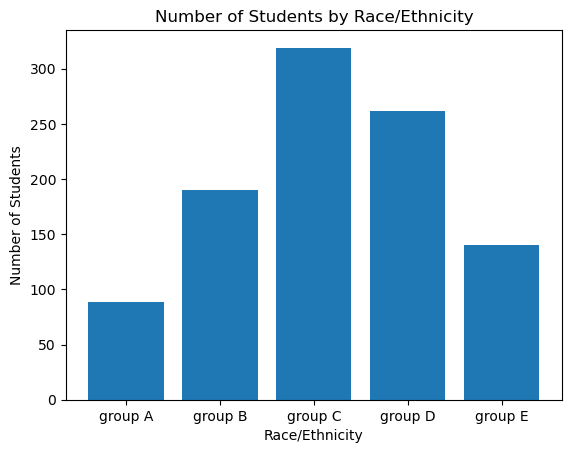

In [18]:
counts = df.groupby("race/ethnicity").count()
race = counts["gender"].reset_index().rename(columns={"gender": "counts"})
#TODO
plt.bar(race["race/ethnicity"], race["counts"])
plt.xlabel("Race/Ethnicity")
plt.ylabel("Number of Students")
plt.title("Number of Students by Race/Ethnicity")
plt.show()

The method you use to create a visualization is up to preference, although in more advanced data you may have a preference for one method over another. Keep both in mind because both are useful!

(TASK 3): Create a bar plot for the parental level of education (remember to label your axes and title).

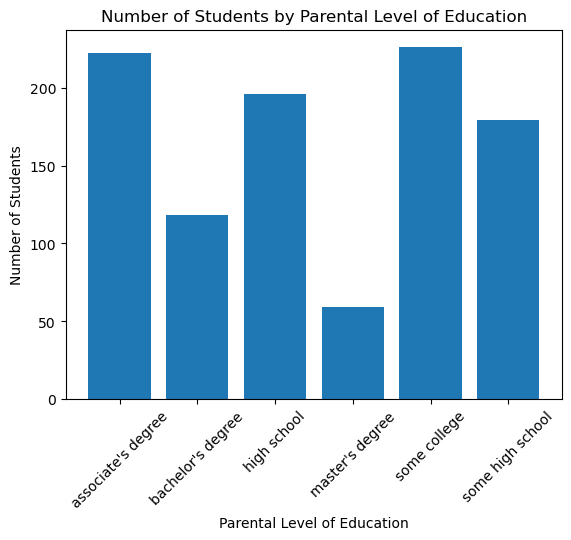

In [21]:
ed = df.groupby("parental level of education").count()
ed = ed["gender"].reset_index().rename(columns={"gender": "counts"})
#TODO
plt.bar(ed["parental level of education"], ed["counts"])
plt.xlabel("Parental Level of Education")
plt.ylabel("Number of Students")
plt.title("Number of Students by Parental Level of Education")
plt.xticks(rotation=45)
plt.show()

# Histograms/Density Curves/KDEs

(TASK 4): Now plot the distribution of math scores in a histogram using seaborn with a density curve laid on top of the histogram. You can use the histplot method for this.

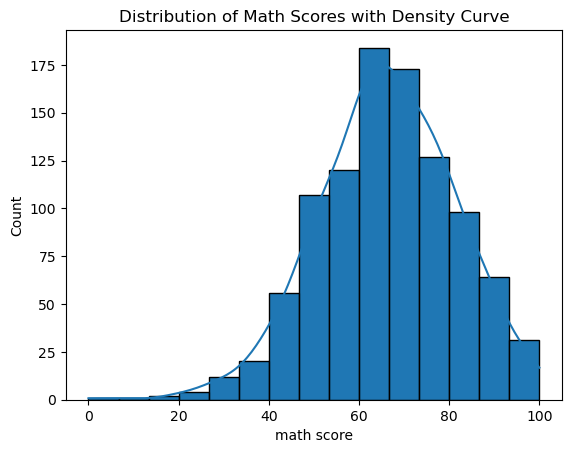

In [25]:
#TODO
math_scores=df["math score"]
plt.hist(math_scores, bins=15)
sns.histplot(df["math score"], bins=15, kde=True)

plt.title("Distribution of Math Scores with Density Curve")
plt.show()


(TASK 5): Now using matplotlib. Plotting a density curve is a more difficult process here, so we'll skip doing it for now. The axes and title labels need to be added.

Text(0.5, 1.0, 'Math Score Distribution with Density Curve')

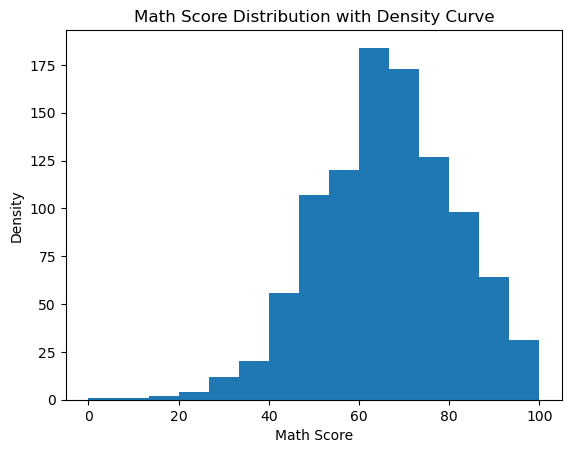

In [28]:
#TODO
math_scores = df["math score"]
plt.hist(math_scores, bins=15)

plt.xlabel("Math Score")
plt.ylabel("Density")
plt.title("Math Score Distribution with Density Curve")


(TASK 6): We'll take some time to understand the skew, outliers, and mode of this histogram. What are the properties of this histogram?

This histogram is unimodal, skewed left sinc eit have a left tail, mode is about 70, and there are some small outliers on the lower end but no hgih outliers. 

Although we could visualize the quartiles within the histogram itself using colors and a legend, it comes out to a somewhat complicated process. If we don't have to include that aspect of visualization, we can do something similar in a box plot (covered later in the notebook)!

(TASK 7): We saw the density curve in the seaborn plot, try plotting just the density curve without the histogram.

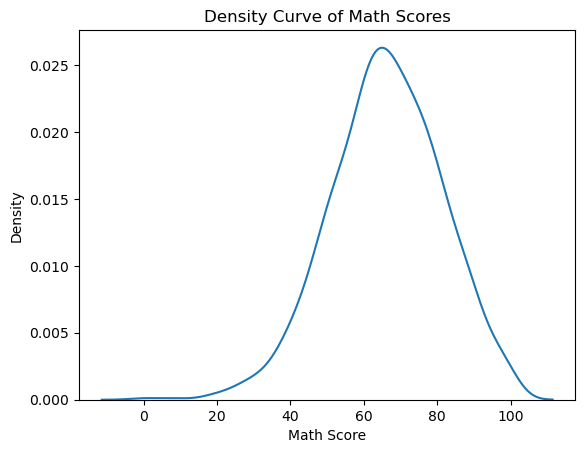

In [29]:
#TODO

sns.kdeplot(df["math score"])
plt.xlabel("Math Score")
plt.ylabel("Density")
plt.title("Density Curve of Math Scores")
plt.show()

# Box Plots/Violin Plots

(TASK 8): Make a box plot of the math scores using matplotlib and seaborn. No need for a title on this plot.

{'whiskers': [<matplotlib.lines.Line2D at 0x10874d1d0>,
 'caps': [<matplotlib.lines.Line2D at 0x10874d450>,
 'boxes': [<matplotlib.lines.Line2D at 0x10874d090>],
 'medians': [<matplotlib.lines.Line2D at 0x10874d6d0>],
 'fliers': [<matplotlib.lines.Line2D at 0x10874d810>],
 'means': []}

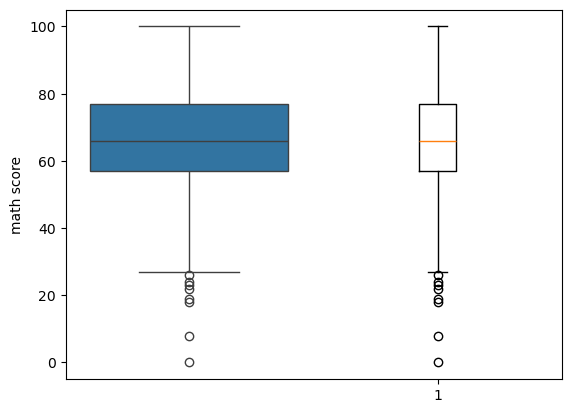

In [32]:
#TODO

sns.boxplot(data=math_scores)
plt.boxplot(math_scores)

(TASK 9): Let's take a second to discuss the properties of the boxplot (median, quartiles, outliers)

The median of the boxplot is around the high 60s, the lower quartile is at the high 50s while the upper quartile is at the high 70s. There are lower outliers in the lower 0 to mid 20s region while there are no upper outliers. 

What about violin plots? Both are useful depending on what you want to accomplish - violin plots better show the distribution of points in an area, while box plots are better at showing outliers as individual points.

(TASK 10): Use seaborn to make a violin plot

<Axes: ylabel='math score'>

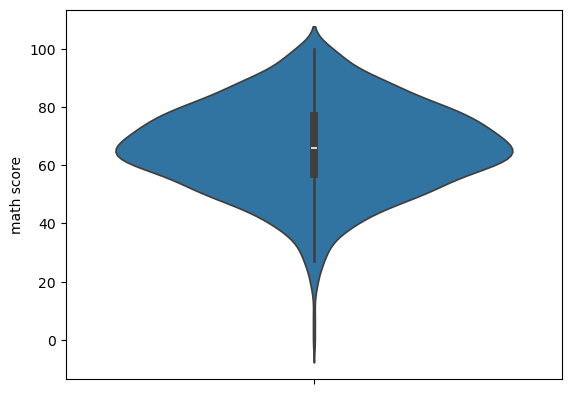

In [34]:
#TODO
sns.violinplot(data=math_scores)

# Scatter Plots

If you want to see if there is some type of trend between two variables, scatter plots are really useful for visualizing it. Let's see if there's a trend between math score and reading score with parental level of education as the hue.

(TASK 11): Make a scatter plot with the x axis corresponding to the math score of each student and the y axis corresponding to the reading score. Plot this scatter plot and make sure that parental level of education is somehow represented.

Text(0.5, 1.0, 'Math Score vs Reading Scores by Parental Level of Education')

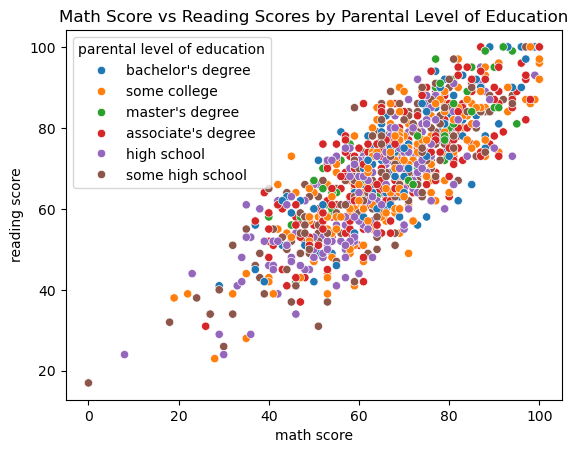

In [39]:
#TODO
sns.scatterplot(data=df, x="math score", y="reading score", hue="parental level of education")
plt.title("Math Score vs Reading Scores by Parental Level of Education")

It's somewhat difficult to understand exactly what's happening in this plot - this is called overfitting. To account for this, either increase the size of the graph or jitter your plot! We won't be doing this here, but keep it in mind when you need to visualize data cleanly.

What about a trend between reading score and writing score? (matplotlib does not have an option for an automatic hue)

(TASK 12): Make a scatter plot of reading and writing score like task 11 without accounting for parental education. Fit a line of best fit so we can visualize the general trend of the data on top of the scatter plot.

Text(0.5, 1.0, 'Reading Scores vs Writing Scores with Line of Best Fit')

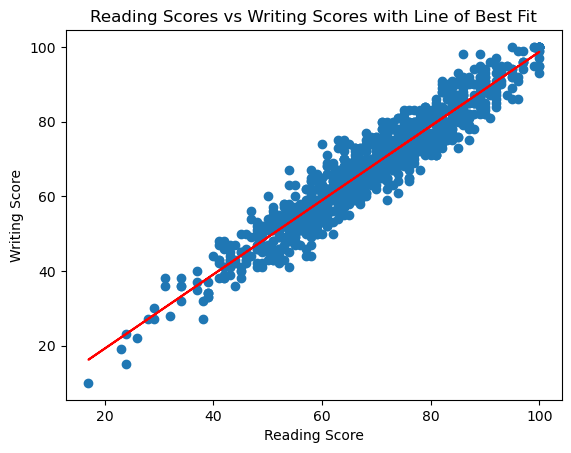

In [45]:
x=df["reading score"]
y=df["writing score"]
plt.scatter(x, y)
slope, intercept= np.polyfit(x, y, 1)
plt.plot(x, slope*x + intercept, color="red")
plt.xlabel("Reading Score")
plt.ylabel("Writing Score")
plt.title("Reading Scores vs Writing Scores with Line of Best Fit")

(TASK 13): What can you compare about these two scatter plots? What information do each of these give us?

The first scatter plot shows the impact of parental education level while the second one doesn't. However, the second plot shows the association between students reading and writing scores especially with the best line of fit.

# Transformations

### We're going to first make a new column so that there is a non-linear relationship
(TASK 14): Make a new column called "reading cubed" which is each student's reading score cubed. Plot this column instead of the regular reading score against each student's math score.

Text(0.5, 1.0, 'Transformed Reading Cubed vs Math Scores')

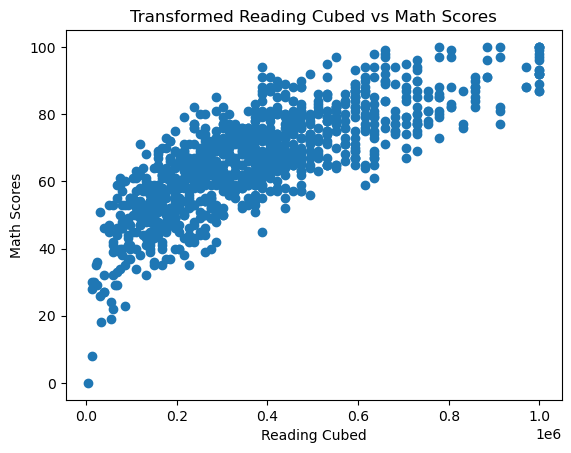

In [51]:
#TODO
df["reading cubed"]=df["reading score"]**3
x=df["reading cubed"]
y=df["math score"]
plt.scatter(x, y)
plt.xlabel("Reading Cubed")
plt.ylabel("Math Scores")
plt.title("Transformed Reading Cubed vs Math Scores")

(TASK 15): As you can see from the scatterplot, the relationship no longer looks linear. What change could we make to the math score to make a linear relationship (reference the Bulge Diagram in the slides if needed)

Create a new column that transforms the math scores so that the new column plotted against reading cubed shows a linear relationship.

Text(0.5, 1.0, 'Transformed Reading Sqrt vs Math Scores')

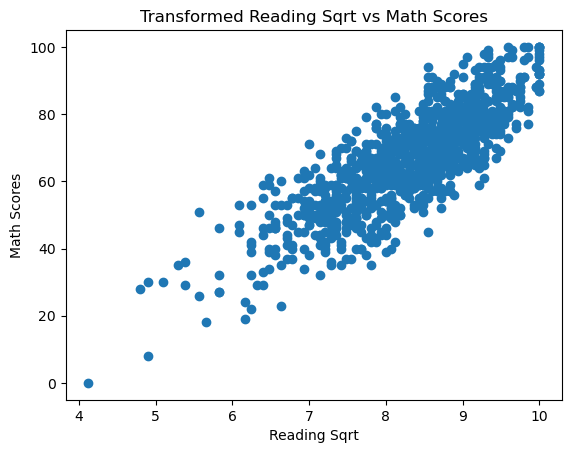

In [50]:
#TODO
df["reading_sqrt"]=np.sqrt(df["reading score"])
x=df["reading_sqrt"]
y=df["math score"]
plt.scatter(x, y)
plt.xlabel("Reading Sqrt")
plt.ylabel("Math Scores")
plt.title("Transformed Reading Sqrt vs Math Scores")